In [11]:
# two_softmax_diff_nnx.py
# Flax nnx 0.11.0
from __future__ import annotations

import jax, jax.numpy as jnp
from flax import nnx
import numpy as np

import matplotlib.pyplot as plt
import optax
from tqdm import tqdm
from jaxpi.ssbroyden_optax import scale_by_ssbroyden_wolfe_oracle

jax.config.update("jax_enable_x64", True)
DTYPE = jnp.float64

In [12]:
class MLP(nnx.Module):

    def __init__(self, layer_sizes: list[int], activation,  *, rngs: nnx.Rngs = nnx.Rngs(0)):
        layers = []
        for i in range(len(layer_sizes) - 2):
            layer = nnx.Linear(layer_sizes[i], layer_sizes[i + 1], rngs=rngs, param_dtype=DTYPE)
            layers.append(layer)
            layers.append(activation)
        layers.append(nnx.Linear(layer_sizes[-2], layer_sizes[-1], rngs=rngs, param_dtype=DTYPE))
        self.layers = nnx.Sequential(*layers)
        

    def __call__(self, x: jnp.ndarray):
        x = self.layers(x)
        return x

In [13]:
# -------------------------
# Two-head difference model
# -------------------------
class TwoSoftmaxDiff(nnx.Module):
    f: nnx.Module
    g: nnx.Module

    def __init__(self,
                 f: nnx.Module,
                 g: nnx.Module,
                 *,
                 softmax_first: bool = False,
                 linear_kwargs: dict = {"in_features": 1, "out_features": 1, "use_bias": False},
                 rngs: nnx.Rngs = nnx.Rngs(0)):
        self.f = f
        self.g = g
        self.softmax_first = softmax_first
        self.linear_transformation = nnx.Linear(**linear_kwargs, rngs=rngs, param_dtype=DTYPE)

    def __call__(self, x: jnp.ndarray):
        """
        Returns:
          y_hat: [...],
          alpha_f: [..., M], alpha_g: [..., M]
        """
        # α_f, α_g
        alpha_f = nnx.softmax(self.f(x), axis=-1)
        alpha_g = nnx.softmax(self.g(x), axis=-1)
        y_hat = self.linear_transformation(alpha_f - alpha_g)
        return y_hat

In [14]:
# -------------------------
# Two-head difference model
# -------------------------
class TwoSoftmaxDiff_separate_weights(nnx.Module):
    f: nnx.Module
    g: nnx.Module

    def __init__(self,
                 f: nnx.Module,
                 g: nnx.Module,
                 *,
                 linear_kwargs: dict = {"in_features": 1, "out_features": 1, "use_bias": False},
                 rngs: nnx.Rngs = nnx.Rngs(0)):
        self.f = f
        self.g = g
        self.lf = nnx.Linear(**linear_kwargs, rngs=rngs, param_dtype=DTYPE)
        self.lg = nnx.Linear(**linear_kwargs, rngs=rngs, param_dtype=DTYPE)

    def __call__(self, x: jnp.ndarray):
        """
        Returns:
          y_hat: [...],
          alpha_f: [..., M], alpha_g: [..., M]
        """
        # α_f, α_g
        alpha_f = nnx.softmax(self.f(x), axis=-1)
        f_hat = self.lf(alpha_f)
        alpha_g = nnx.softmax(self.g(x), axis=-1)
        g_hat = self.lg(alpha_g)
        y_hat = f_hat - g_hat
        return y_hat

In [15]:
# =========================
# Target function & metrics
# =========================
def f_sin(x: jnp.ndarray, k: int) -> jnp.ndarray:
    return jnp.sin(2.0 * jnp.pi * DTYPE(k) * x)


def error_metrics(y_hat: jnp.ndarray, y_true: jnp.ndarray):
    err = jnp.abs(y_hat - y_true)
    rmse = jnp.sqrt(jnp.mean((y_hat - y_true) ** 2))
    linf = jnp.max(err)
    return rmse, linf

In [16]:
# Training functions
def loss_fn(model, x: jnp.ndarray, y: jnp.ndarray):
    y_hat = model(x)
    return jnp.mean((y_hat - y) ** 2)

def rel_l2_error(model, x_eval, y_eval):
    y_hat = model(x_eval)
    return jnp.linalg.norm(y_hat - y_eval) / jnp.linalg.norm(y_eval)

@nnx.jit
def train_step(model, optimizer: nnx.Optimizer, x: jnp.ndarray, y: jnp.ndarray):
    loss, grads = nnx.value_and_grad(loss_fn)(model, x, y)
    optimizer = optimizer.update(model, grads)
    return loss

In [25]:
def run_experiment_broyden_mlp(
    M: int = 33,
    k: int = 3,
    # training
    steps: int = 50000, 
    n_train: int = 4097,
    n_eval: int = 10000,
    rng: nnx.Rngs = nnx.Rngs(0),

):  
    print("Performing reference training for MLP")
    
    # training grid
    x_train = jnp.linspace(-1.0, 1.0, n_train, dtype=DTYPE).reshape(-1, 1)
    y_train = f_sin(x_train, k).reshape(-1, 1)

    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE).reshape(-1, 1)
    y_eval = f_sin(x_eval, k).reshape(-1, 1)

    model = MLP([1, M, M, 1], nnx.tanh , rngs = rng)
    # save initial model

    init_graphdef, init_state = nnx.split(model)
    init_model = nnx.merge(init_graphdef, init_state)

    # Create the optimizer pipeline
    # Build an (f,g) oracle that accepts a PARAMS-like pytree.
    # It reconstructs a temporary model using a static GraphDef.
    def make_fg_oracle(graphdef, base_state):
        """Oracle f(params, x, y) that rebuilds the model and stamps in `params` arrays."""
        base_state_pure = nnx.freeze(nnx.pure(base_state))  # pure arrays FlatState

        def f(params, x, y):
            # 1) reconstruct Node from the static graph + base state
            node = nnx.merge(graphdef, base_state_pure)
            # 2) stamp the param arrays into the live Node (structure must match nnx.Param tree)
            nnx.update(node, params)
            # 3) compute loss
            return loss_fn(node, x, y)

        return nnx.jit(nnx.value_and_grad(f, argnums=0))

    tx = scale_by_ssbroyden_wolfe_oracle(lr=1.0, c1=1e-4, c2=0.9, max_ls=20)

    # Wrap with the NNX optimizer (wrt=nnx.Param is required in 0.11)
    optim = nnx.Optimizer(model, tx, wrt=nnx.Param)  # kwargs will be forwarded to tx.update(...) :contentReference[oaicite:2]{index=2}

    # Build the oracle once from a static graphdef
    graphdef, base_state = nnx.split(model)                 # base_state is the full FlatState (Params + Variables)
    base_state = nnx.freeze(nnx.pure(base_state))           # make it a pure arrays pytree for JIT-friendliness
    fg_oracle = make_fg_oracle(graphdef, base_state)

    @nnx.jit
    def train_step_b(model, opt, x, y):
        # grads w.r.t. model Params
        def cur_loss(m): return loss_fn(m, x, y)
        f_k, grads = nnx.value_and_grad(cur_loss, argnums=nnx.DiffState(0, nnx.Param))(model)

        # Pass oracle + runtime tensors via **kwargs (forwarded to tx.update)
        opt.update(model, grads, f_k=f_k, fg_oracle=fg_oracle, loss_args=(x, y))
        return f_k

    # training loop
    pbar = tqdm(range(steps), desc="training")
    print("Initial eval rel L2:", rel_l2_error(model, x_eval, y_eval))
    for i in pbar:
        loss = train_step_b(model, optim, x_train, y_train)
        if i % 10 == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            pbar.set_description(f"step {i}, train loss={loss:.3e}, eval rel L2={eval_error:.3e}")
    
    return model, init_model

In [26]:
model_mlp , init_model_mlp = run_experiment_broyden_mlp(M=64, k=16,
                       steps=50000, n_train=2048, n_eval=10000, rng=nnx.Rngs(42))

Performing reference training for MLP


training:   0%|          | 0/50000 [00:00<?, ?it/s]

Initial eval rel L2: 1.005962038473554


step 49990, train loss=9.824e-12, eval rel L2=4.432e-06: 100%|██████████| 50000/50000 [31:01<00:00, 26.86it/s]


In [17]:
def run_experiment_broyden(
    M: int = 33,
    k: int = 3,
    # training
    steps: int = 50000, 
    n_train: int = 4097,
    n_eval: int = 10000,
    *,
    separate_weights: bool = False,
    rng: nnx.Rngs = nnx.Rngs(0),

):
    
    
    # training grid
    x_train = jnp.linspace(-1.0, 1.0, n_train, dtype=DTYPE).reshape(-1, 1)
    y_train = f_sin(x_train, k).reshape(-1, 1)

    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE).reshape(-1, 1)
    y_eval = f_sin(x_eval, k).reshape(-1, 1)

    f = MLP([1, M, M], nnx.tanh , rngs = rng)
    g = MLP([1, M, M], nnx.tanh , rngs = rng)

    # init model with ε*
    if separate_weights:
        model = TwoSoftmaxDiff_separate_weights(f, g, linear_kwargs={"in_features": M, "out_features": 1, "use_bias": True}, rngs=rng)
    else:
        model = TwoSoftmaxDiff(f, g, linear_kwargs={"in_features": M, "out_features": 1, "use_bias": True}, rngs=rng)

    init_graphdef, init_state = nnx.split(model)
    init_model = nnx.merge(init_graphdef, init_state)

    # Create the optimizer pipeline
    # Build an (f,g) oracle that accepts a PARAMS-like pytree.
    # It reconstructs a temporary model using a static GraphDef.
    def make_fg_oracle(graphdef, base_state):
        """Oracle f(params, x, y) that rebuilds the model and stamps in `params` arrays."""
        base_state_pure = nnx.freeze(nnx.pure(base_state))  # pure arrays FlatState

        def f(params, x, y):
            # 1) reconstruct Node from the static graph + base state
            node = nnx.merge(graphdef, base_state_pure)
            # 2) stamp the param arrays into the live Node (structure must match nnx.Param tree)
            nnx.update(node, params)
            # 3) compute loss
            return loss_fn(node, x, y)

        return nnx.jit(nnx.value_and_grad(f, argnums=0))

    tx = scale_by_ssbroyden_wolfe_oracle(lr=1.0, c1=1e-4, c2=0.9, max_ls=20)

    # Wrap with the NNX optimizer (wrt=nnx.Param is required in 0.11)
    optim = nnx.Optimizer(model, tx, wrt=nnx.Param)  # kwargs will be forwarded to tx.update(...) :contentReference[oaicite:2]{index=2}

    # Build the oracle once from a static graphdef
    graphdef, base_state = nnx.split(model)                 # base_state is the full FlatState (Params + Variables)
    base_state = nnx.freeze(nnx.pure(base_state))           # make it a pure arrays pytree for JIT-friendliness
    fg_oracle = make_fg_oracle(graphdef, base_state)

    @nnx.jit
    def train_step_b(model, opt, x, y):
        # grads w.r.t. model Params
        def cur_loss(m): return loss_fn(m, x, y)
        f_k, grads = nnx.value_and_grad(cur_loss, argnums=nnx.DiffState(0, nnx.Param))(model)

        # Pass oracle + runtime tensors via **kwargs (forwarded to tx.update)
        opt.update(model, grads, f_k=f_k, fg_oracle=fg_oracle, loss_args=(x, y))
        return f_k

    # training loop
    pbar = tqdm(range(steps), desc="training")
    print("Initial eval rel L2:", rel_l2_error(model, x_eval, y_eval))
    for i in pbar:
        loss = train_step_b(model, optim, x_train, y_train)
        if i % 10 == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            pbar.set_description(f"step {i}, train loss={loss:.3e}, eval rel L2={eval_error:.3e}")
    
    return model, init_model

In [18]:
k = 16
model, init_model = run_experiment_broyden(M=64, k=k,
                       steps=10000, n_train=400, n_eval=20000, rng=nnx.Rngs(0), separate_weights = False)

training:   0%|          | 0/10000 [00:00<?, ?it/s]

Initial eval rel L2: 0.9998594296660952


step 210, train loss=8.858e-02, eval rel L2=4.201e-01:   2%|▏         | 220/10000 [00:17<13:04, 12.46it/s]


KeyboardInterrupt: 

In [ ]:
def nnx_compatible(tx: optax.GradientTransformation) -> optax.GradientTransformation:
    def init_fn(params):
        # strip NNX Variables -> pure arrays
        return tx.init(nnx.pure(params))
    def update_fn(updates, state, params=None, **kwargs):
        # grads/updates & params may be Variable pytrees in NNX
        updates = nnx.pure(updates)
        if params is not None:
            params = nnx.pure(params)
        return tx.update(updates, state, params=params, **kwargs)
    return optax.GradientTransformation(init_fn, update_fn)


def run_experiment(
    M: int = 33,
    k: int = 3,
    # training
    steps: int = 50000, 
    n_train: int = 4097,
    n_eval: int = 10000,
    lr: float = 1e-2,
    *,
    separate_weights: bool = False,
    rng: nnx.Rngs = nnx.Rngs(0),

):
    
    # training grid
    x_train = jnp.linspace(-1.0, 1.0, n_train, dtype=DTYPE).reshape(-1, 1)
    y_train = f_sin(x_train, k).reshape(-1, 1)

    x_eval = jnp.linspace(-1.0, 1.0, n_eval, dtype=DTYPE).reshape(-1, 1)
    y_eval = f_sin(x_eval, k).reshape(-1, 1)

    f = MLP([1, M], nnx.tanh , rngs = rng)
    g = MLP([1, M], nnx.tanh , rngs = rng)

    # init model with ε*
    if separate_weights:
        model = TwoSoftmaxDiff_separate_weights(f, g, linear_kwargs={"in_features": M, "out_features": 1, "use_bias": False}, rngs=rng)
    else:
        model = TwoSoftmaxDiff(f, g, linear_kwargs={"in_features": M, "out_features": 1, "use_bias": False}, rngs=rng)

    #optim = nnx.Optimizer(model, optax.adam(learning_rate=lr), wrt=nnx.Param)  # kwargs will be forwarded to tx.update(...) :contentReference[oaicite:2]{index=2}
    optim = nnx.Optimizer(model, optax.sgd(learning_rate=lr), wrt=nnx.Param)  # kwargs will be forwarded to tx.update(...) :contentReference[oaicite:2]{index=2}
    # --- in your run_experiment() just replace the failing line with:
    #tx = nnx_compatible(optax.contrib.muon(learning_rate=lr))
    #optim = nnx.Optimizer(model, tx, wrt=nnx.Param)

    # training loop
    pbar = tqdm(range(steps), desc="training")
    for i in pbar:
        loss = train_step(model, optim, x_train, y_train)
        if i % 1000 == 0:
            eval_error = rel_l2_error(model, x_eval, y_eval)
            pbar.set_description(f"step {i}, train loss={loss:.3e}, eval rel L2={eval_error:.3e}")
    
    return model


In [ ]:
# k = 1
# model, init_model = run_experiment_broyden(M=128, k=k,
#                        steps=10000, n_train=2049, n_eval=20000)

In [ ]:
# --------------------------
# Two-softmax barycentric head (no sign gate)
# --------------------------
class _BucketLogKernel(nnx.Module):
    xi: nnx.Param      # [Mp] or [Mn]
    beta: nnx.Param    # [Mp] or [Mn]  (usually log|w_j|)
    y: nnx.Param       # [Mp] or [Mn]
    tau: DTYPE
    delta: DTYPE

    def __init__(self, xi, y, beta, tau=1.0, delta=1e-18, *, rngs=None):
        self.xi   = nnx.Param(jnp.asarray(xi, dtype=DTYPE))
        self.beta = nnx.Param(jnp.asarray(beta, dtype=DTYPE))
        self.y    = nnx.Param(jnp.asarray(y, dtype=DTYPE))
        self.tau  = DTYPE(tau)
        self.delta= DTYPE(delta)

    def logits(self, x):  # [..., Mbucket]
        d = jnp.abs(x[..., None] - self.xi[None, ...]) + self.delta
        return -self.tau * jnp.log(d) + self.beta[None, ...]

    def mean_and_logZ(self, x):
        L = self.logits(x)
        m = jnp.max(L, axis=-1, keepdims=True)
        U = L - m
        expU = jnp.exp(U)
        Z   = jnp.sum(expU, axis=-1, keepdims=True)      # = exp(logZ - m)
        alpha = expU / Z                                  # softmax within bucket
        mu = jnp.einsum('...k,k->...', alpha, self.y)     # bucket mean of y
        logZ = m[..., 0] + jnp.log(Z[..., 0] + 1e-300)    # collapse keepdims safely
        return mu, logZ

class TwoSoftmaxBarycentric(nnx.Module):
    pos: _BucketLogKernel
    neg: _BucketLogKernel
    node_atol: DTYPE

    def __init__(self, xi, y, w, tau=1.0, delta=1e-18, node_atol=1e-18, *, rngs=None):
        xi = jnp.asarray(xi, dtype=DTYPE)
        y  = jnp.asarray(y,  dtype=DTYPE)
        w  = jnp.asarray(w,  dtype=DTYPE)

        pos_mask = w > 0
        neg_mask = w < 0
        xi_p, y_p, b_p = xi[pos_mask], y[pos_mask], jnp.log(jnp.abs(w[pos_mask]) + 1e-300)
        xi_n, y_n, b_n = xi[neg_mask], y[neg_mask], jnp.log(jnp.abs(w[neg_mask]) + 1e-300)

        self.pos = _BucketLogKernel(xi_p, y_p, b_p, tau=tau, delta=delta)
        self.neg = _BucketLogKernel(xi_n, y_n, b_n, tau=tau, delta=delta)
        self.node_atol = DTYPE(node_atol)

    def __call__(self, x):
        # bucket means and log-normalizers
        mu_p, a = self.pos.mean_and_logZ(x)   # a = log Z_P
        mu_n, b = self.neg.mean_and_logZ(x)   # b = log Z_N

        # stable combine: (e^a mu_p - e^b mu_n) / (e^a - e^b)
        c  = jnp.maximum(a, b)
        ea = jnp.exp(a - c)
        eb = jnp.exp(b - c)
        y_hat = (ea * mu_p - eb * mu_n) / (ea - eb + 1e-300)

        # Exact-node replacement (x==xi_k -> y_k), per Berrut–Trefethen
        # (division by zero is removable; override those points)
        # Combine both buckets' nodes
        xi_all = jnp.concatenate([self.pos.xi, self.neg.xi], axis=0)
        y_all  = jnp.concatenate([self.pos.y,  self.neg.y ], axis=0)
        dmin   = jnp.min(jnp.abs(x[..., None] - xi_all[None, ...]), axis=-1)
        at_node = dmin <= self.node_atol

        def pick_exact(x_row):
            k = jnp.argmin(jnp.abs(x_row - xi_all))
            return y_all[k]

        if at_node.ndim == 0:
            y_exact = pick_exact(x)
            y_hat = jnp.where(at_node, y_exact, y_hat)
        else:
            y_exact = jax.vmap(pick_exact)(x)
            y_hat = jnp.where(at_node, y_exact, y_hat)

        return y_hat


In [ ]:
# --------------------------
# Chebyshev–Lobatto utilities
# --------------------------
def cheb_lobatto_nodes(K: int) -> jnp.ndarray:
    j = jnp.arange(K + 1, dtype=DTYPE)
    return jnp.cos(jnp.pi * j / K)

def lobatto_bary_weights(K: int) -> jnp.ndarray:
    # w_j = (-1)^j * c_j,  c_0=c_K=1/2 else 1
    j = jnp.arange(K + 1, dtype=jnp.int32)
    sign = 1 - 2 * (j % 2)  # (-1)^j
    c = jnp.ones_like(sign, dtype=DTYPE)
    c = c.at[0].set(0.5).at[K].set(0.5)
    return sign.astype(DTYPE) * c

M   = 33
xi0 = cheb_lobatto_nodes(M-1)               # ξ_j
w0  = lobatto_bary_weights(M-1)             # (-1)^j with endpoint 1/2
y0  = jnp.sin(2*jnp.pi*xi0)

model = TwoSoftmaxBarycentric(xi0, y0, w0, tau=1.0, delta=1e-18, node_atol=1e-18)

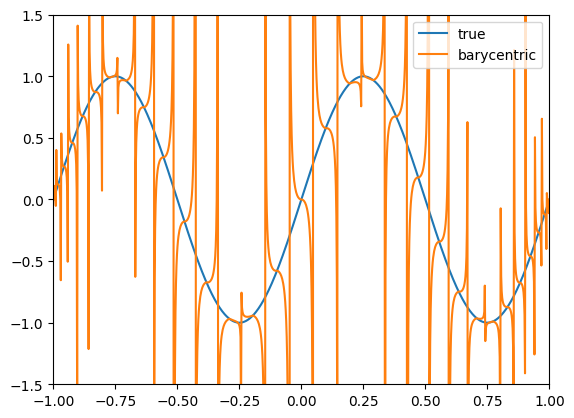

In [ ]:
x = jnp.linspace(-1.0, 1.0, 1000, dtype=DTYPE)

model(x).shape

plt.plot(x, f_sin(x, 1), label="true")
plt.plot(x, model(x), label="barycentric")
plt.xlim(-1, 1)
plt.ylim(-1.5, 1.5)
plt.legend()
plt.show()
